In [1]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.


In [7]:
DATA_DIR = "/kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data"

In [8]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-"*50)
    break

Folder: /kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data
Subfolders: ['val', 'test', 'train']
Files: 1
--------------------------------------------------


In [9]:
print(os.listdir(DATA_DIR + "/train"))

['Pituitary', 'Ependymoma', 'Medulloblastoma', 'No_Tumor', 'Schwannoma', 'Astrocytoma', 'Glioblastoma', 'Oligodendroglioma', 'Meningioma', 'Germinoma']


Verify extraction

In [ ]:
# DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/brain tumer prediction/data'

In [ ]:
# import os

# DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/brain tumer prediction/data'
# print(os.listdir(DATA_DIR))

In [13]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-04-29 20:43:06.721831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777495387.206938      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777495387.334102      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777495388.422260      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777495388.422299      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777495388.422302      57 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [16]:
import tensorflow as tf

# Check GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Enable memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Enable mixed precision
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



🧠 CUSTOM CNN - BRAIN TUMOR CLASSIFICATION
Based on: Ishfaq et al. (2025) - Scientific Reports
Using PRE-AUGMENTED Data
✅ Found: /kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data/train
✅ Found: /kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data/val
✅ Found: /kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data/test

🏗️  Building Custom CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777495542.529031      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777495542.535060      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Model compiled successfully
   Optimizer: Adam (lr=0.001)
   Loss: Categorical Crossentropy
   Metrics: Accuracy, Precision, Recall

📋 Model Architecture:


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

860/860 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9644 - loss: 0.1179 - precision: 0.9685 - recall: 0.9606 - val_accuracy: 0.9501 - val_loss: 0.2020 - val_precision: 0.9580 - val_recall: 0.9463 - learning_rate: 0.0010
Epoch 14/30
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9740 - loss: 0.0923 - precision: 0.9768 - recall: 0.9711
Epoch 14: val_accuracy did not improve from 0.95007
860/860 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.9740 - loss: 0.0923 - precision: 0.9768 - recall: 0.9711 - val_accuracy: 0.9463 - val_loss: 0.2178 - val_precision: 0.9519 - val_recall: 0.9406 - learning_rate: 0.0010
Epoch 15/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9732 - loss: 0.0950 - precision: 0.9755 - recall: 0.9699
Epoch 15: val_accuracy did not improve from 0.95007
860/860 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9732 - loss: 0.0950 - precision: 0.9755 - recall: 0.9699 - val_accuracy: 0.9297 - val_loss: 0.2572 - val_precision: 0.9363 - val_recall: 0.

860/860 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9708 - loss: 0.1005 - precision: 0.9725 - recall: 0.9694 - val_accuracy: 0.9555 - val_loss: 0.1744 - val_precision: 0.9606 - val_recall: 0.9514 - learning_rate: 0.0010
Epoch 17/30
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9770 - loss: 0.0816 - precision: 0.9795 - recall: 0.9740
Epoch 17: val_accuracy did not improve from 0.95550
860/860 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9770 - loss: 0.0816 - precision: 0.9795 - recall: 0.9740 - val_accuracy: 0.9480 - val_loss: 0.2316 - val_precision: 0.9530 - val_recall: 0.9436 - learning_rate: 0.0010
Epoch 18/30
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9808 - loss: 0.0699 - precision: 0.9834 - recall: 0.9782
Epoch 18: val_accuracy did not improve from 0.95550
860/860 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9808 - loss: 0.0699 - precision: 0.9834 - recall: 0.9782 - val_accuracy: 0.9514 - val_loss: 0.1897 - val_precision: 0.9596 - val_recall: 0.

860/860 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9763 - loss: 0.0800 - precision: 0.9787 - recall: 0.9746 - val_accuracy: 0.9626 - val_loss: 0.1717 - val_precision: 0.9665 - val_recall: 0.9596 - learning_rate: 0.0010
Epoch 21/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9793 - loss: 0.0720 - precision: 0.9811 - recall: 0.9775
Epoch 21: val_accuracy did not improve from 0.96264
860/860 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9793 - loss: 0.0720 - precision: 0.9811 - recall: 0.9775 - val_accuracy: 0.9572 - val_loss: 0.2096 - val_precision: 0.9613 - val_recall: 0.9528 - learning_rate: 0.0010
Epoch 22/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9800 - loss: 0.0759 - precision: 0.9817 - recall: 0.9784
Epoch 22: val_accuracy did not improve from 0.96264
860/860 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9800 - loss: 0.0759 - precision: 0.9817 - recall: 0.9784 - val_accuracy: 0.9535 - val_loss: 0.2000 - val_precision: 0.9592 - val_recall: 0.

860/860 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9790 - loss: 0.0799 - precision: 0.9812 - recall: 0.9778 - val_accuracy: 0.9643 - val_loss: 0.1605 - val_precision: 0.9694 - val_recall: 0.9586 - learning_rate: 0.0010
Epoch 25/30
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9802 - loss: 0.0784 - precision: 0.9819 - recall: 0.9782
Epoch 25: val_accuracy did not improve from 0.96433
860/860 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9802 - loss: 0.0784 - precision: 0.9819 - recall: 0.9782 - val_accuracy: 0.9599 - val_loss: 0.1972 - val_precision: 0.9643 - val_recall: 0.9545 - learning_rate: 0.0010
Epoch 26/30
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9792 - loss: 0.0847 - precision: 0.9805 - recall: 0.9780
Epoch 26: val_accuracy did not improve from 0.96433
860/860 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9792 - loss: 0.0847 - precision: 0.9805 - recall: 0.9780 - val_accuracy: 0.9572 - val_loss: 0.2056 - val_precision: 0.9610 - val_recall: 0.


✅ Training completed!
💾 Final model saved to: /kaggle/working/output/custom_cnn_final.h5
📊 Training history plot saved to: /kaggle/working/output/training_history.png


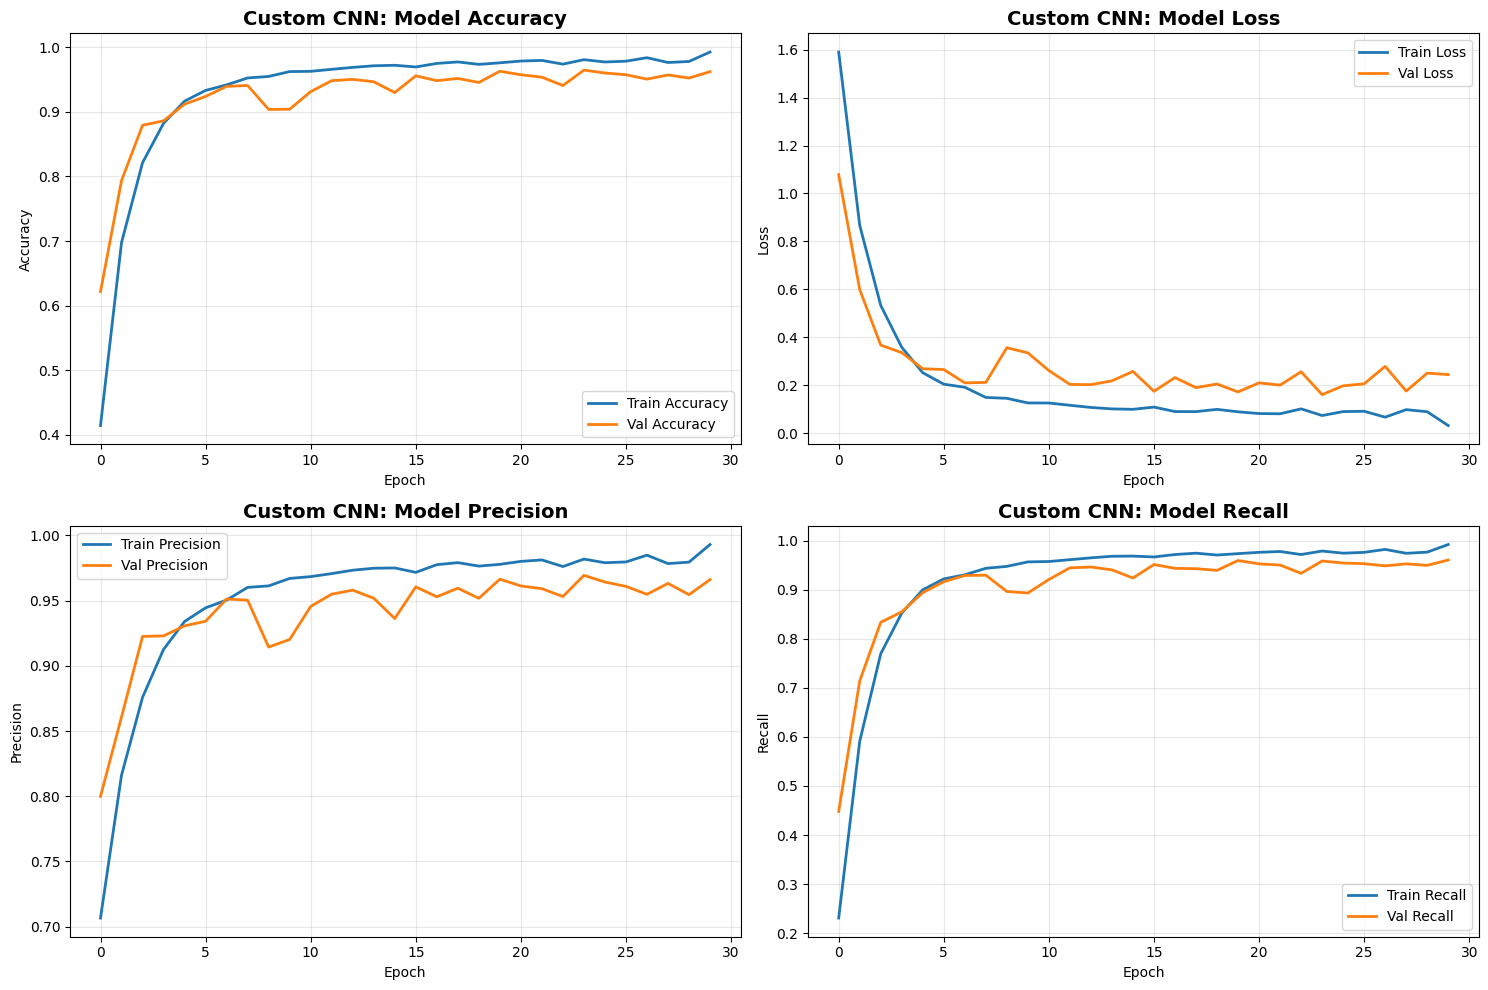


🧪 EVALUATING ON TEST SET - CUSTOM CNN
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9227 - loss: 0.3376 - precision: 0.9348 - recall: 0.9152

📊 Test Results:
   Accuracy:  95.77%
   Precision: 96.44%
   Recall:    95.36%
   F1-Score:  95.90%
   Loss:      0.1817

🔮 Generating predictions...
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step

📋 Classification Report:
                   precision    recall  f1-score   support

      Astrocytoma     0.9029    0.8144    0.8564       194
       Ependymoma     0.9627    0.9281    0.9451       278
        Germinoma     0.9789    0.9754    0.9772       285
     Glioblastoma     0.9596    0.9667    0.9631       270
  Medulloblastoma     0.9542    0.9644    0.9593       281
       Meningioma     0.9973    0.9691    0.9830       388
         No_Tumor     0.9944    0.9833    0.9888       360
Oligodendroglioma     0.9345    0.9625    0.9483       267
        Pituitary     0.9756    0.9975    0.9864       400
       Schwannoma     0.8543    0.939

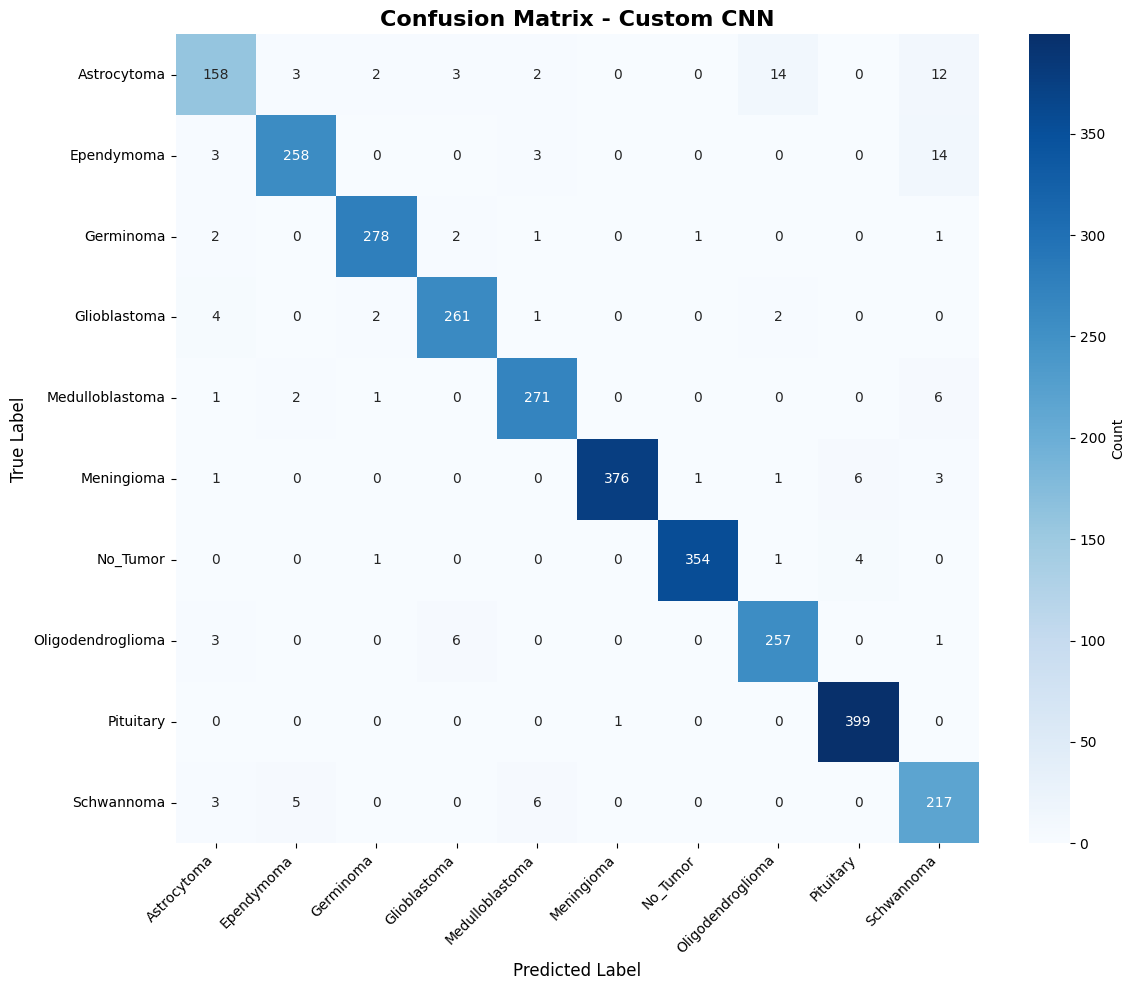

💾 Test results saved to: /kaggle/working/output/test_results.json

✅ TRAINING AND EVALUATION COMPLETE!
📂 All results saved to: /kaggle/working/output/
   - custom_cnn_best.h5 (best model)
   - custom_cnn_final.h5 (final model)
   - training_history.csv
   - training_history.png
   - confusion_matrix.png
   - classification_report.txt
   - test_results.json


In [18]:
"""
Custom CNN Model for Brain Tumor Classification
Based on: Ishfaq et al. (2025) - Scientific Reports

IMPORTANT: This version uses ALREADY PREPROCESSED AND AUGMENTED data
No additional augmentation is applied during training

Architecture Details:
- 5 Convolutional layers (32, 64, 128, 256, 512 filters)
- Max pooling after each conv layer
- 3 Fully connected layers (1024, 512, 10)
- ReLU activation
- Input size: 224x224x3
- Output: 10 classes
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


class CustomCNN:
    """
    Custom CNN Model for Brain Tumor Classification
    """

    def __init__(self, input_shape=(224, 224, 3), num_classes=10):
        """
        Initialize the Custom CNN model

        Args:
            input_shape: Input image dimensions (height, width, channels)
            num_classes: Number of tumor classes
        """
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.history = None
        self.class_names = None

    def build_model(self):
        """
        Build the Custom CNN architecture as described in the paper
        """
        model = models.Sequential(name='Custom_CNN')

        # Convolutional Layer 1: 32 filters, 3x3 kernel
        model.add(layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same',
                                activation='relu', input_shape=self.input_shape, name='conv1'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool1'))

        # Convolutional Layer 2: 64 filters, 3x3 kernel
        model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same',
                                activation='relu', name='conv2'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool2'))

        # Convolutional Layer 3: 128 filters, 3x3 kernel
        model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding='same',
                                activation='relu', name='conv3'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool3'))

        # Convolutional Layer 4: 256 filters, 3x3 kernel
        model.add(layers.Conv2D(256, (3, 3), strides=(1, 1), padding='same',
                                activation='relu', name='conv4'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool4'))

        # Convolutional Layer 5: 512 filters, 3x3 kernel
        model.add(layers.Conv2D(512, (3, 3), strides=(1, 1), padding='same',
                                activation='relu', name='conv5'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool5'))

        # Flatten
        model.add(layers.Flatten(name='flatten'))

        # Fully Connected Layer 1: 1024 units
        model.add(layers.Dense(1024, activation='relu', name='fc1'))
        model.add(layers.Dropout(0.5, name='dropout1'))

        # Fully Connected Layer 2: 512 units
        model.add(layers.Dense(512, activation='relu', name='fc2'))
        model.add(layers.Dropout(0.5, name='dropout2'))

        # Output Layer: num_classes units with softmax
        model.add(layers.Dense(self.num_classes, activation='softmax', name='fc3'))

        self.model = model
        return model

    def compile_model(self, learning_rate=0.001):
        """
        Compile the model with optimizer and loss function

        Args:
            learning_rate: Learning rate for Adam optimizer
        """
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        self.model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
        )

        print("✅ Model compiled successfully")
        print(f"   Optimizer: Adam (lr={learning_rate})")
        print(f"   Loss: Categorical Crossentropy")
        print(f"   Metrics: Accuracy, Precision, Recall")

    def get_model_summary(self):
        """Print model architecture summary"""
        return self.model.summary()

    def count_parameters(self):
        """Count total and trainable parameters"""
        total_params = self.model.count_params()
        trainable_params = sum([np.prod(v.shape) for v in self.model.trainable_weights])

        print(f"\n📊 Model Parameters:")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable parameters: {trainable_params:,}")
        print(f"   Non-trainable parameters: {total_params - trainable_params:,}")

        return total_params, trainable_params


class BrainTumorTrainer:
    """
    Training pipeline for brain tumor classification
    """

    def __init__(self, data_dir, model, batch_size=64, image_size=(224, 224)):
        """
        Initialize trainer

        Args:
            data_dir: Path to data directory (should contain train/val/test folders)
            model: CustomCNN model instance
            batch_size: Batch size for training
            image_size: Input image size
        """
        self.data_dir = Path(data_dir)
        self.model = model
        self.batch_size = batch_size
        self.image_size = image_size

        self.train_dir = self.data_dir / 'train'
        self.val_dir = self.data_dir / 'val'
        self.test_dir = self.data_dir / 'test'

        # Data generators
        self.train_generator = None
        self.val_generator = None
        self.test_generator = None

    def setup_data_generators(self):
        """
        Setup data generators WITHOUT augmentation
        (Data is already preprocessed and augmented)
        """
        print("\n" + "=" * 80)
        print("📊 SETTING UP DATA GENERATORS")
        print("=" * 80)
        print("⚠️  Using PRE-AUGMENTED data - No additional augmentation applied")
        print("=" * 80)

        # All generators only rescale (data already augmented)
        train_datagen = ImageDataGenerator(rescale=1./255)
        val_datagen = ImageDataGenerator(rescale=1./255)
        test_datagen = ImageDataGenerator(rescale=1./255)

        # Create generators
        self.train_generator = train_datagen.flow_from_directory(
            self.train_dir,
            target_size=self.image_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
        )

        self.val_generator = val_datagen.flow_from_directory(
            self.val_dir,
            target_size=self.image_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            shuffle=False
        )

        self.test_generator = test_datagen.flow_from_directory(
            self.test_dir,
            target_size=self.image_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            shuffle=False
        )

        # Store class names
        self.model.class_names = list(self.train_generator.class_indices.keys())

        print(f"\n📈 Dataset Statistics:")
        print(f"   Training samples: {self.train_generator.samples}")
        print(f"   Validation samples: {self.val_generator.samples}")
        print(f"   Test samples: {self.test_generator.samples}")
        print(f"   Number of classes: {self.train_generator.num_classes}")
        print(f"   Class names: {self.model.class_names}")
        print("=" * 80)

    def train(self, epochs=30, save_dir='models'):
        """
        Train the model

        Args:
            epochs: Number of training epochs
            save_dir: Directory to save model and results
        """
        # Create save directory
        save_dir = Path(save_dir)
        save_dir.mkdir(exist_ok=True, parents=True)

        print("\n" + "=" * 80)
        print("🚀 STARTING TRAINING - CUSTOM CNN")
        print("=" * 80)
        print(f"Epochs: {epochs}")
        print(f"Batch size: {self.batch_size}")
        print(f"Save directory: {save_dir}")
        print("=" * 80)

        # Callbacks
        callbacks = [
            # Save best model
            ModelCheckpoint(
                filepath=str(save_dir / 'custom_cnn_best.h5'),
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1
            ),

            # Early stopping
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),

            # Reduce learning rate on plateau
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),

            # CSV logger
            CSVLogger(
                filename=str(save_dir / 'training_history.csv'),
                separator=',',
                append=False
            )
        ]

        # Train model
        self.model.history = self.model.model.fit(
            self.train_generator,
            epochs=epochs,
            validation_data=self.val_generator,
            callbacks=callbacks,
            verbose=1
        )

        print("\n✅ Training completed!")

        # Save final model
        final_model_path = save_dir / 'custom_cnn_final.h5'
        self.model.model.save(final_model_path)
        print(f"💾 Final model saved to: {final_model_path}")

        return self.model.history

    def plot_training_history(self, save_dir='models'):
        """
        Plot training history
        """
        history = self.model.history.history
        save_dir = Path(save_dir)

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Accuracy
        axes[0, 0].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
        axes[0, 0].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2)
        axes[0, 0].set_title('Custom CNN: Model Accuracy', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

        # Loss
        axes[0, 1].plot(history['loss'], label='Train Loss', linewidth=2)
        axes[0, 1].plot(history['val_loss'], label='Val Loss', linewidth=2)
        axes[0, 1].set_title('Custom CNN: Model Loss', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

        # Precision
        axes[1, 0].plot(history['precision'], label='Train Precision', linewidth=2)
        axes[1, 0].plot(history['val_precision'], label='Val Precision', linewidth=2)
        axes[1, 0].set_title('Custom CNN: Model Precision', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        # Recall
        axes[1, 1].plot(history['recall'], label='Train Recall', linewidth=2)
        axes[1, 1].plot(history['val_recall'], label='Val Recall', linewidth=2)
        axes[1, 1].set_title('Custom CNN: Model Recall', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

        plt.tight_layout()

        plot_path = save_dir / 'training_history.png'
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"📊 Training history plot saved to: {plot_path}")
        plt.show()

    def evaluate_on_test(self, save_dir='models'):
        """
        Evaluate model on test set
        """
        print("\n" + "=" * 80)
        print("🧪 EVALUATING ON TEST SET - CUSTOM CNN")
        print("=" * 80)

        save_dir = Path(save_dir)

        # Evaluate
        test_loss, test_accuracy, test_precision, test_recall = self.model.model.evaluate(
            self.test_generator,
            verbose=1
        )

        # Calculate F1 score
        test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

        print(f"\n📊 Test Results:")
        print(f"   Accuracy:  {test_accuracy*100:.2f}%")
        print(f"   Precision: {test_precision*100:.2f}%")
        print(f"   Recall:    {test_recall*100:.2f}%")
        print(f"   F1-Score:  {test_f1*100:.2f}%")
        print(f"   Loss:      {test_loss:.4f}")

        # Get predictions
        print("\n🔮 Generating predictions...")
        self.test_generator.reset()
        predictions = self.model.model.predict(self.test_generator, verbose=1)
        y_pred = np.argmax(predictions, axis=1)
        y_true = self.test_generator.classes

        # Classification report
        print("\n📋 Classification Report:")
        print("=" * 80)
        report = classification_report(
            y_true, y_pred,
            target_names=self.model.class_names,
            digits=4
        )
        print(report)

        # Save classification report
        report_path = save_dir / 'classification_report.txt'
        with open(report_path, 'w') as f:
            f.write("Custom CNN Classification Report\n")
            f.write("=" * 80 + "\n")
            f.write(report)
        print(f"💾 Classification report saved to: {report_path}")

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Plot confusion matrix
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.model.class_names,
                    yticklabels=self.model.class_names,
                    cbar_kws={'label': 'Count'})
        plt.title('Confusion Matrix - Custom CNN', fontsize=16, fontweight='bold')
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        cm_path = save_dir / 'confusion_matrix.png'
        plt.savefig(cm_path, dpi=300, bbox_inches='tight')
        print(f"📊 Confusion matrix saved to: {cm_path}")
        plt.show()

        # Save test results
        results = {
            'model': 'Custom CNN',
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'test_accuracy': float(test_accuracy),
            'test_precision': float(test_precision),
            'test_recall': float(test_recall),
            'test_f1_score': float(test_f1),
            'test_loss': float(test_loss),
            'confusion_matrix': cm.tolist(),
            'class_names': self.model.class_names
        }

        results_path = save_dir / 'test_results.json'
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"💾 Test results saved to: {results_path}")

        print("=" * 80)

        return test_accuracy, test_precision, test_recall, test_f1


def main():
    """
    Main execution function
    """
    print("\n" + "=" * 80)
    print("🧠 CUSTOM CNN - BRAIN TUMOR CLASSIFICATION")
    print("Based on: Ishfaq et al. (2025) - Scientific Reports")
    print("Using PRE-AUGMENTED Data")
    print("=" * 80)

    # Configuration
    DATA_DIR = '/kaggle/input/datasets/fazilsiddiqui/brain-tumor-dataset-10-classes/data'
    SAVE_DIR = '/kaggle/working/output'

    IMAGE_SIZE = (128,128)  #(224, 224)
    BATCH_SIZE = 16  ## 64 or 32
    EPOCHS = 30
    LEARNING_RATE = 0.001
    NUM_CLASSES = 10

    # Check if data directory exists
    if not os.path.exists(DATA_DIR):
        print(f"\n❌ Error: Data directory '{DATA_DIR}' not found!")
        print("Please check the path")
        return

    # Verify train/val/test subdirectories
    required_dirs = ['train', 'val', 'test']
    for subdir in required_dirs:
        full_path = os.path.join(DATA_DIR, subdir)
        if not os.path.exists(full_path):
            print(f"❌ Error: '{subdir}' directory not found in {DATA_DIR}")
            return
        print(f"✅ Found: {full_path}")

    # Create model
    print("\n🏗️  Building Custom CNN model...")
    cnn_model = CustomCNN(
        input_shape=(*IMAGE_SIZE, 3),
        num_classes=NUM_CLASSES
    )

    cnn_model.build_model()
    cnn_model.compile_model(learning_rate=LEARNING_RATE)

    # Print model summary
    print("\n📋 Model Architecture:")
    print("=" * 80)
    cnn_model.get_model_summary()
    cnn_model.count_parameters()

    # Create trainer
    trainer = BrainTumorTrainer(
        data_dir=DATA_DIR,
        model=cnn_model,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE
    )

    # Setup data generators (NO augmentation - data already augmented)
    trainer.setup_data_generators()

    # Train model
    history = trainer.train(epochs=EPOCHS, save_dir=SAVE_DIR)

    # Plot training history
    trainer.plot_training_history(save_dir=SAVE_DIR)

    # Evaluate on test set
    trainer.evaluate_on_test(save_dir=SAVE_DIR)

    print("\n" + "=" * 80)
    print("✅ TRAINING AND EVALUATION COMPLETE!")
    print("=" * 80)
    print(f"📂 All results saved to: {SAVE_DIR}/")
    print("   - custom_cnn_best.h5 (best model)")
    print("   - custom_cnn_final.h5 (final model)")
    print("   - training_history.csv")
    print("   - training_history.png")
    print("   - confusion_matrix.png")
    print("   - classification_report.txt")
    print("   - test_results.json")
    print("=" * 80)


if __name__ == "__main__":
    main()
